/tmp/ipykernel_3799/2626459348.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


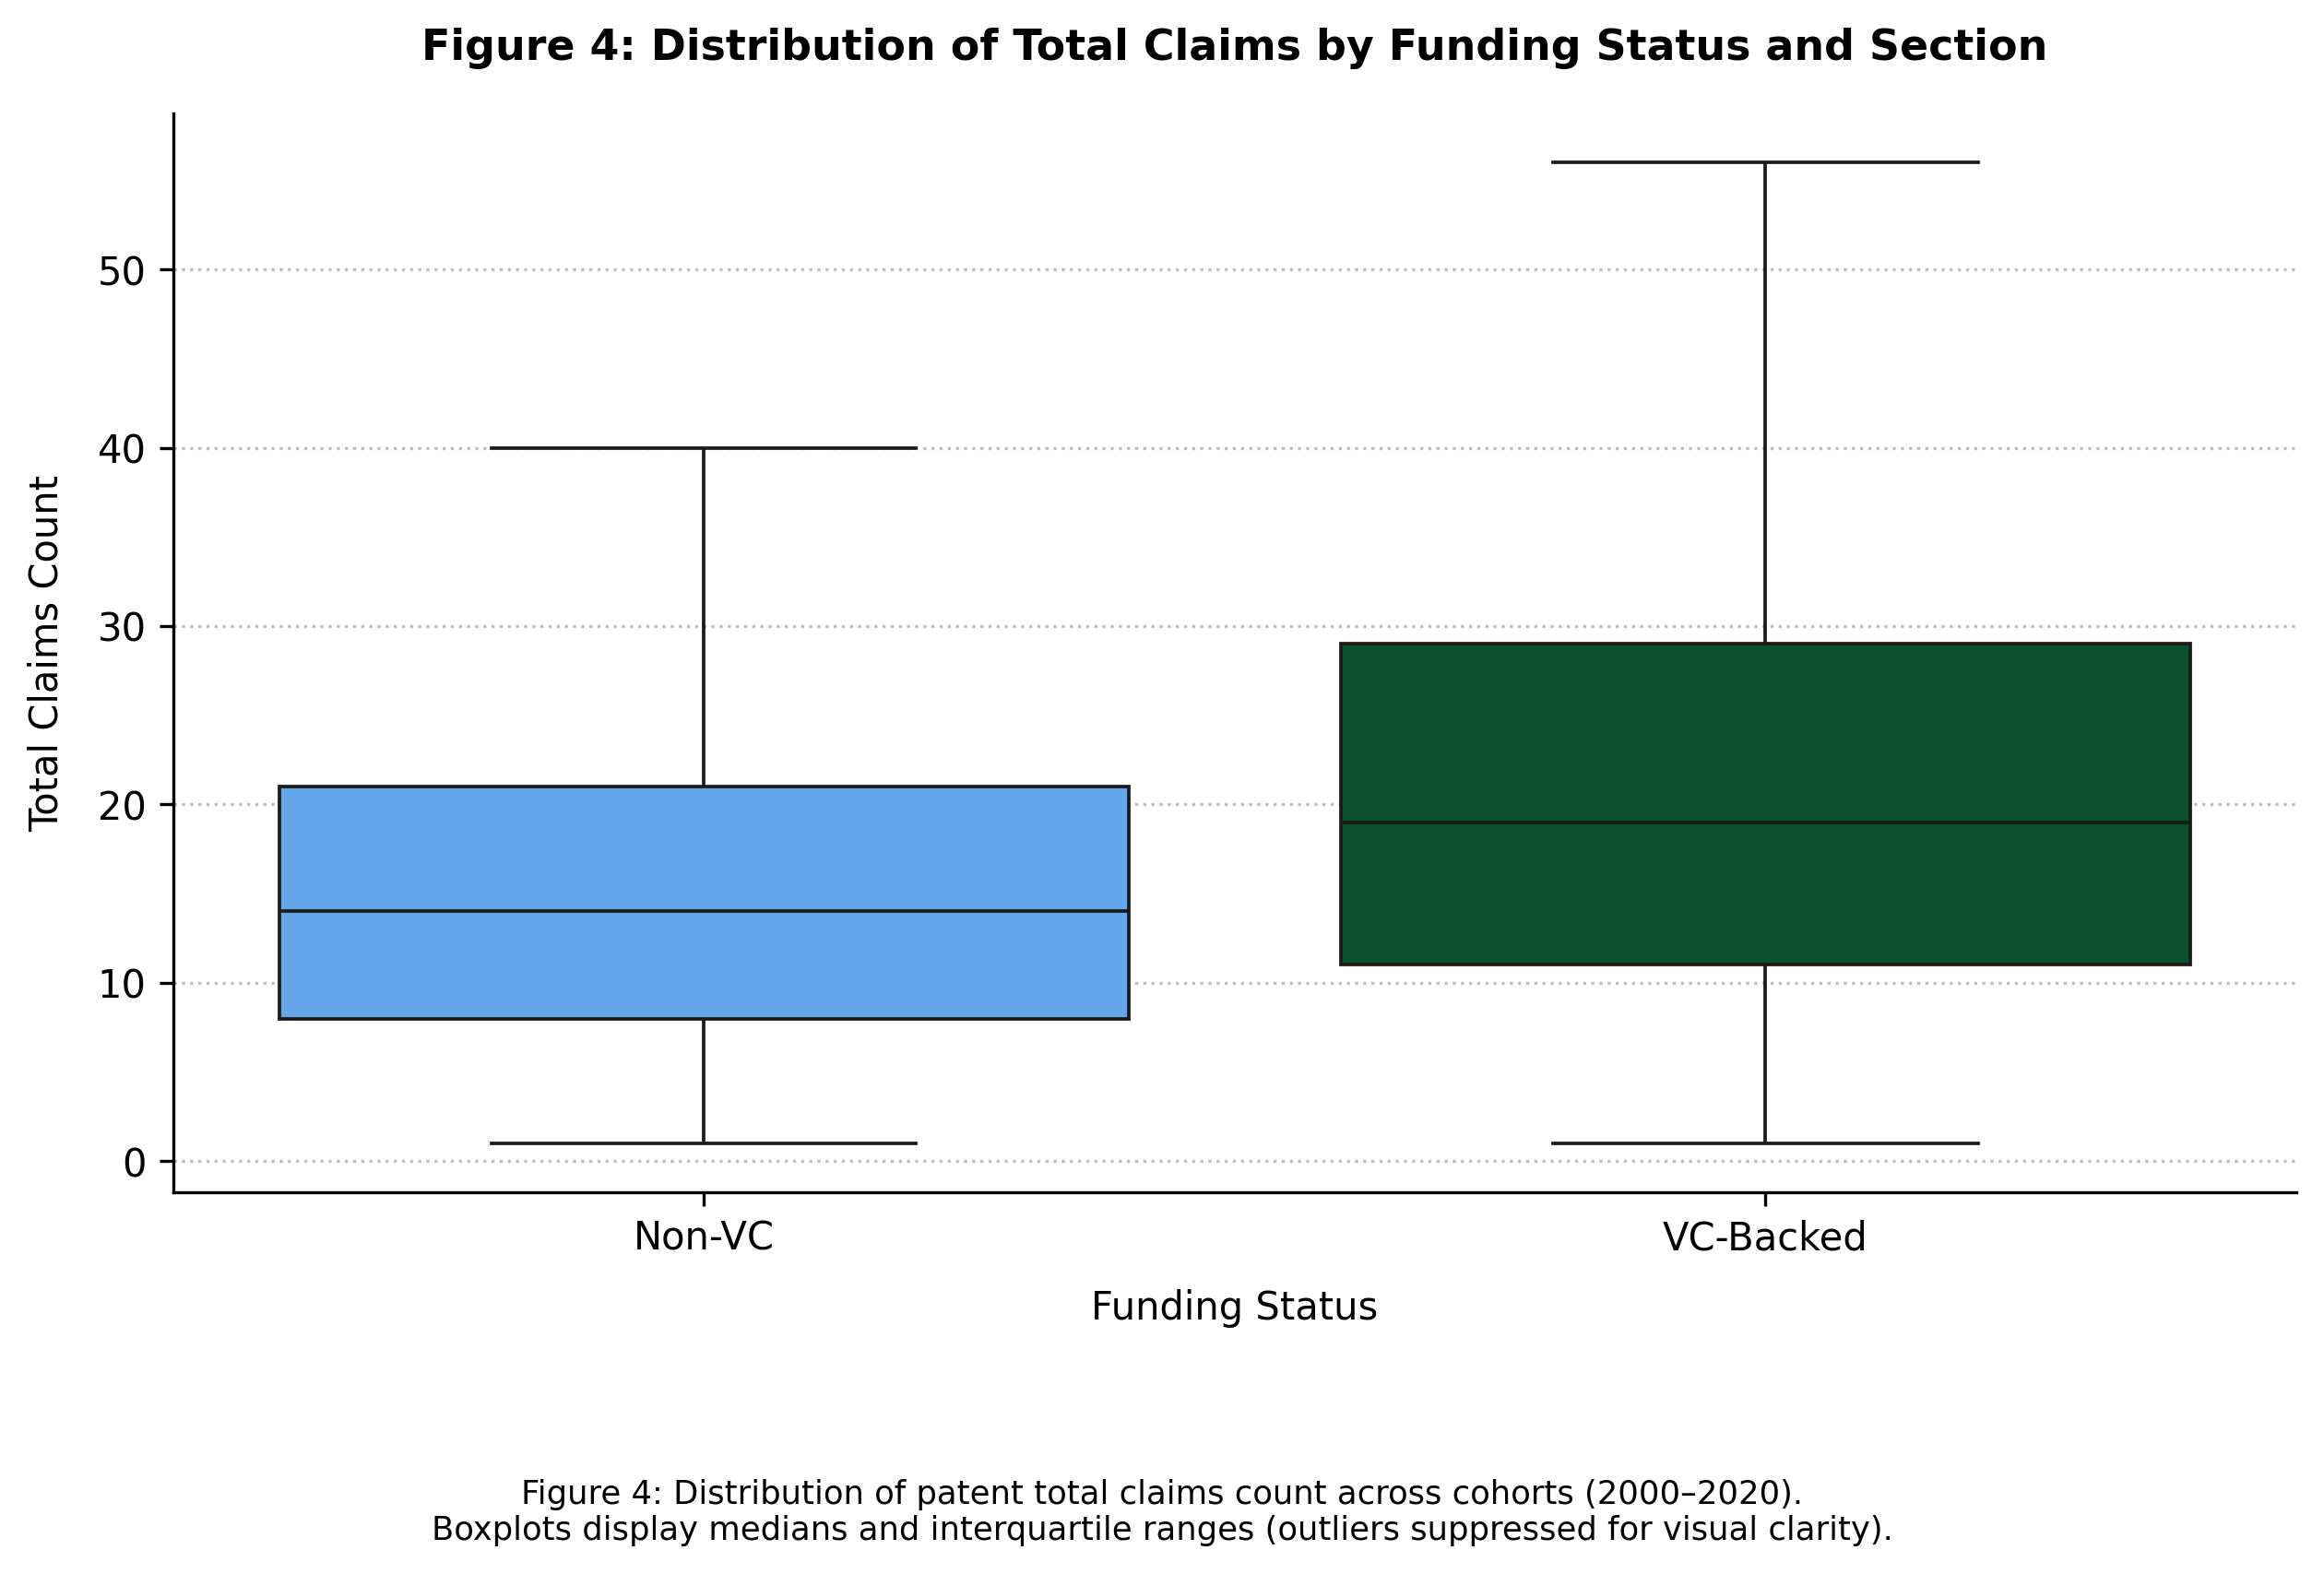

In [ ]:
#figure 4

import os
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

#functions
def load_claims_distribution_data(parquet_file, start_year=2000, end_year=2020):
    con = duckdb.connect()
    df = con.execute(f"""
        SELECT
            cpc_section,
            CASE WHEN vc_backed = 1 THEN 'VC-Backed' ELSE 'Non-VC' END AS vc_status,
            total_claims
        FROM '{parquet_file}'
        WHERE total_claims IS NOT NULL
          AND total_claims > 0
          AND grant_year BETWEEN {start_year} AND {end_year};
    """).df()
    return df

def configure_plot_style():
    plt.rcParams.update({
        'font.size': 10,
        'font.family': 'sans-serif',
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.edgecolor': '#000000',
        'grid.color': '#000000',
        'grid.alpha': 0.25
    })

def plot_claims_distribution(df, output_path, valid_sections=None):
    if valid_sections is None:
        valid_sections = ['A', 'B', 'C', 'F', 'G', 'H']

    if df[df['cpc_section'].isin(valid_sections)].shape[0] > 100:
        df_plot = df[df['cpc_section'].isin(valid_sections)].copy()
        x_col = 'cpc_section'
        x_label = 'CPC Technology Section'
    else:
        df_plot = df.copy()
        x_col = 'vc_status'
        x_label = 'Funding Status'

    fig, ax = plt.subplots(figsize=(8.5, 5), dpi=300)

    sns.boxplot(
        data=df_plot,
        x=x_col,
        y='total_claims',
        hue='vc_status' if x_col != 'vc_status' else None,
        palette={'VC-Backed': '#4da6ff', 'Non-VC': '#005a32'} if x_col != 'vc_status' else ['#4da6ff', '#005a32'],
        showfliers=False,
        linewidth=0.9,
        ax=ax
    )

    ax.set_title('Figure 4: Distribution of Total Claims by Funding Status and Section', fontsize=11, fontweight='bold', pad=14)
    ax.set_xlabel(x_label, fontsize=10, labelpad=8)
    ax.set_ylabel('Total Claims Count', fontsize=10, labelpad=8)
    ax.grid(True, linestyle=':', axis='y')

    if x_col != 'vc_status':
        ax.legend(title='Funding Status', frameon=True, loc='upper right')

    caption = (
        "Figure 4: Distribution of patent total claims count across cohorts (2000–2020).\n"
        "Boxplots display medians and interquartile ranges (outliers suppressed for visual clarity)."
    )
    plt.figtext(0.5, -0.12, caption, wrap=True, horizontalalignment='center', fontsize=8.5, color='#000000')

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

#setup paths and load data
drive_mount_point = os.path.join(os.sep, "content", "drive")
drive.mount(drive_mount_point, force_remount=False)

drive_data_dir = os.path.join(drive_mount_point, "MyDrive", "data")
parquet_path = os.path.join(drive_data_dir, "cleaned_patent_panel.parquet")

#load dataset
df_claims = load_claims_distribution_data(parquet_path, start_year=2000, end_year=2020)


configure_plot_style()
fig4_path = os.path.join(drive_data_dir, "figure4_claims_distribution.png")
plot_claims_distribution(df_claims, fig4_path)